# K-Nearest Neighbors

En este script de Python veremos como implementar en código todo lo que vimos ya conceptualmente. Python tiene muchas funciones que nos facilitan la vida, y por eso es importante saber qué es lo que está haciendo la computadora cuando hacemos código, y no sólo escribir código a lo tonto.

**Solución:** https://colab.research.google.com/drive/1K1C9bB-N3-fGahS2bKqKxk6xqzFT8Qut?usp=sharing

**Challenge:** https://colab.research.google.com/drive/1WURa0gHeXUMBrd1E14n3_mHz5WT8DRpC?usp=sharing

### Paso 1: Importamos las principales bibliotecas que vamos a utilizar en la sesión.
Abrá otras que importareamos después según vayamos requiriendo las funciones

In [388]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

%matplotlib inline

### Paso 2: descargo e importo la base de datos

In [389]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/d546eaee765268bf2f487608c537c05e22e4b221/iris.csv'

In [390]:
iris = pd.read_csv(url)
iris.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [391]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Imaginémonos que nuestro KNN va a clasificar con base en dos atributos nada más. ¿Qué vemos en la gráfica? Los azules todo bien pero, ¿es clara la "diferencia" entre naranjas y verdes? ¿Cómo lo podríamos solucionar?


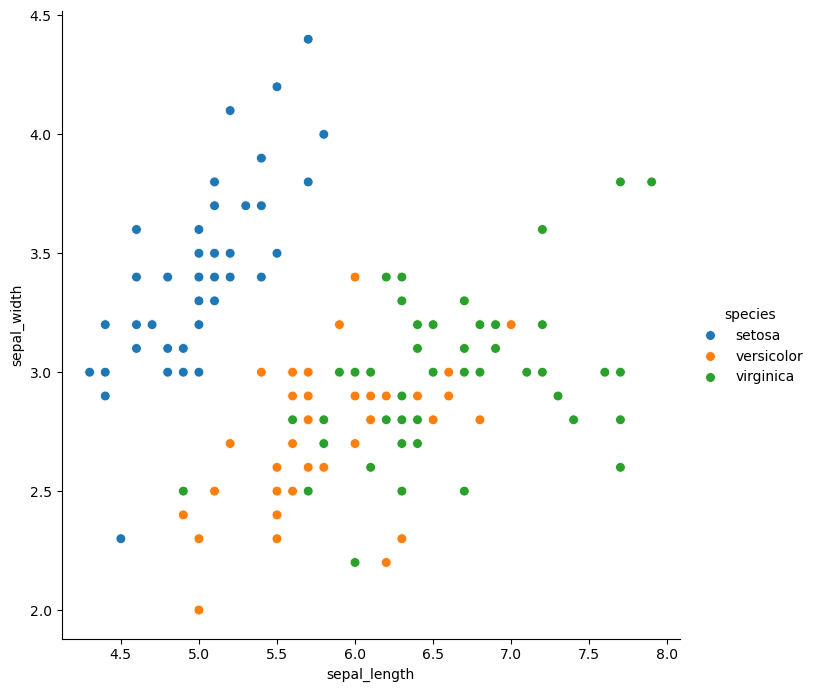

In [392]:
sns.pairplot(x_vars='sepal_length', y_vars='sepal_width', data= iris, plot_kws={'s':50}, height= 7  ,hue= 'species')

### Paso 3: Separo mi base en atributos (variables independientes, si quieren verlo así) y etiquetas (variable dependiente)

In [393]:
#Quiero obtener estos datos en formato de arreglo, lo hace numpy, no en un data frame
x = iris.iloc[: , 0:4].values
x

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [394]:
#estamos asegurando que los datos tengan una correspondencia de 1 a 1
#Procurar no hacer reordenamiento para conservar los indices, para que los valores de predicción coincidan con los valores de entrenamiento
y = iris.iloc[:, 4].values
y

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

#¿Knearest ?

![knearest](https://miro.medium.com/max/1022/1*AuXDgGrr0wbCoF6KDXXSZQ.jpeg)


El algoritmo k-nearest neighbors (KNN) es un algoritmo de aprendizaje automático simple y supervisado que puede utilizarse para resolver tanto problemas de clasificación como de regresión. Es fácil de implementar y entender, pero tiene el gran inconveniente de volverse significativamente lento a medida que crece el tamaño de los datos en uso.
KNN funciona encontrando las distancias entre una consulta y todos los ejemplos de los datos, seleccionando el número especificado de ejemplos (K) más cercanos a la consulta, y luego vota por la etiqueta más frecuente (en el caso de la clasificación) o promedia las etiquetas (en el caso de la regresión).
En el caso de la clasificación y la regresión, la elección de la K correcta para nuestros datos se realiza probando varias K y eligiendo la que mejor funciona.


En la clasificación k-NN, el resultado es la pertenencia a una clase. Un objeto se clasifica mediante un voto plural de sus vecinos, asignando el objeto a la clase más común entre sus k vecinos más cercanos (k es un número entero positivo, normalmente pequeño). Si k = 1, el objeto se asigna simplemente a la clase de ese único vecino más cercano.

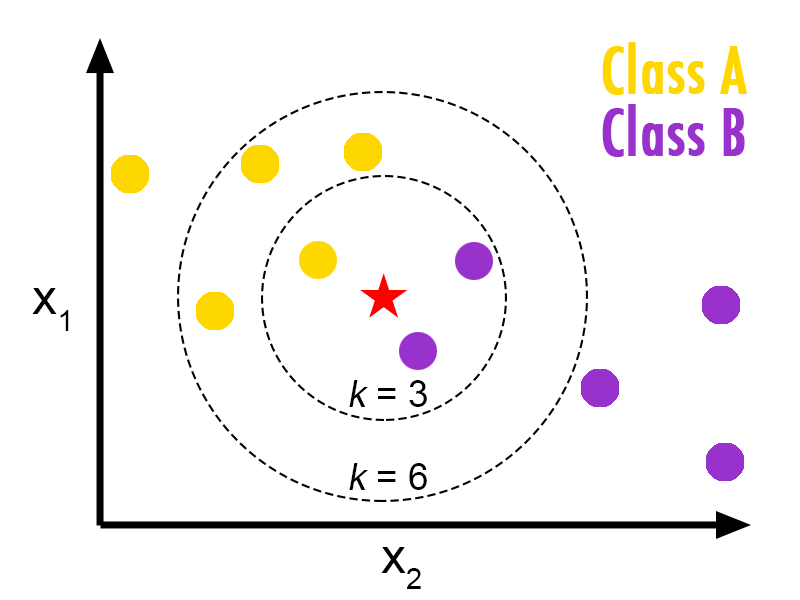

![tomato](https://jiayiwangjw.github.io/img/KNN/tomato.png)

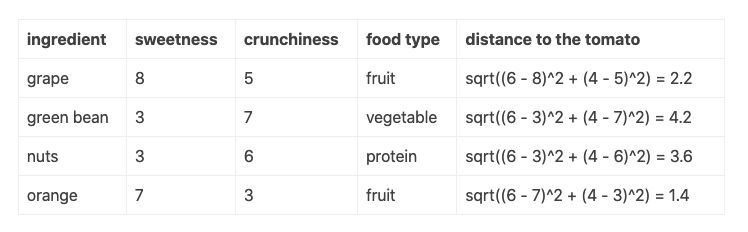

### Paso 4: Vamos a dividir nuestra base en una base de entrenamiento y otra de prueba. Dejemos 80% para que el KNN memorice, y 20% para ver qué tan bien "aprendió" a clasificar

In [395]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state= 42) #Aquí separa en set de entrenamiento y un set de prueba, se pasa aquí las puras features (solo caracteristicas , no respuestas), y el valor semilla nos permite hacer el muestreo aleotorio de los datos de la misma manera
#En test size los valores intermedio, es ilogico valores de 0 o 1 porque esos son los valores que va entrenar, en este caso el 0.2 representa el 20% de los datos
#estos son los valores de entrada: x_train = variable de entrenamiento, luego la de prueba, en otra variable vendrá las respuestas del entrenamiento y_train, y luego las respuestas de la prueba (80%)

In [396]:
#Conjunto de entrenamiento
print(x_train)
len(x_train)

[[4.6 3.6 1.  0.2]
 [5.7 4.4 1.5 0.4]
 [6.7 3.1 4.4 1.4]
 [4.8 3.4 1.6 0.2]
 [4.4 3.2 1.3 0.2]
 [6.3 2.5 5.  1.9]
 [6.4 3.2 4.5 1.5]
 [5.2 3.5 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.2 4.1 1.5 0.1]
 [5.8 2.7 5.1 1.9]
 [6.  3.4 4.5 1.6]
 [6.7 3.1 4.7 1.5]
 [5.4 3.9 1.3 0.4]
 [5.4 3.7 1.5 0.2]
 [5.5 2.4 3.7 1. ]
 [6.3 2.8 5.1 1.5]
 [6.4 3.1 5.5 1.8]
 [6.6 3.  4.4 1.4]
 [7.2 3.6 6.1 2.5]
 [5.7 2.9 4.2 1.3]
 [7.6 3.  6.6 2.1]
 [5.6 3.  4.5 1.5]
 [5.1 3.5 1.4 0.2]
 [7.7 2.8 6.7 2. ]
 [5.8 2.7 4.1 1. ]
 [5.2 3.4 1.4 0.2]
 [5.  3.5 1.3 0.3]
 [5.1 3.8 1.9 0.4]
 [5.  2.  3.5 1. ]
 [6.3 2.7 4.9 1.8]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.1 3.3 1.7 0.5]
 [5.6 2.7 4.2 1.3]
 [5.1 3.4 1.5 0.2]
 [5.7 3.  4.2 1.2]
 [7.7 3.8 6.7 2.2]
 [4.6 3.2 1.4 0.2]
 [6.2 2.9 4.3 1.3]
 [5.7 2.5 5.  2. ]
 [5.5 4.2 1.4 0.2]
 [6.  3.  4.8 1.8]
 [5.8 2.7 5.1 1.9]
 [6.  2.2 4.  1. ]
 [5.4 3.  4.5 1.5]
 [6.2 3.4 5.4 2.3]
 [5.5 2.3 4.  1.3]
 [5.4 3.9 1.7 0.4]
 [5.  2.3 3.3 1. ]
 [6.4 2.7 5.3 1.9]
 [5.  3.3 1.4 0.2]
 [5.  3.2 1.

120

In [397]:
#Conjunto de prueba
print(x_test)
len(x_test)


[[6.1 2.8 4.7 1.2]
 [5.7 3.8 1.7 0.3]
 [7.7 2.6 6.9 2.3]
 [6.  2.9 4.5 1.5]
 [6.8 2.8 4.8 1.4]
 [5.4 3.4 1.5 0.4]
 [5.6 2.9 3.6 1.3]
 [6.9 3.1 5.1 2.3]
 [6.2 2.2 4.5 1.5]
 [5.8 2.7 3.9 1.2]
 [6.5 3.2 5.1 2. ]
 [4.8 3.  1.4 0.1]
 [5.5 3.5 1.3 0.2]
 [4.9 3.1 1.5 0.1]
 [5.1 3.8 1.5 0.3]
 [6.3 3.3 4.7 1.6]
 [6.5 3.  5.8 2.2]
 [5.6 2.5 3.9 1.1]
 [5.7 2.8 4.5 1.3]
 [6.4 2.8 5.6 2.2]
 [4.7 3.2 1.6 0.2]
 [6.1 3.  4.9 1.8]
 [5.  3.4 1.6 0.4]
 [6.4 2.8 5.6 2.1]
 [7.9 3.8 6.4 2. ]
 [6.7 3.  5.2 2.3]
 [6.7 2.5 5.8 1.8]
 [6.8 3.2 5.9 2.3]
 [4.8 3.  1.4 0.3]
 [4.8 3.1 1.6 0.2]]


30

En teoría, una buena K para empezar a explorar es la raíz cuadrada del número de observaciones de mi base de entrenamiento. En este caso es la raíz de 120, es decir, 11 aproximadamente.

In [398]:
import math
math.sqrt(len(x_train))

10.954451150103322

![good_k](https://jiayiwangjw.github.io/img/KNN/how%20much%20is%20K.png)

### Paso 5: Normalizo mis datos para que tengan una escala común

Primero importo la función que me permite normalizar facilmente, y luego le digo que calcule media y desviación que va a usar luego para normalizar (en la parte del fit).

In [399]:
from sklearn.preprocessing import  MinMaxScaler  #Een este caso es un escalador de minimos y máximos, nos sirve para resolver este problema de que los min y máximos no coinciden. Nos dimos cuenta en nuestro resumen estadístico.
scaler = MinMaxScaler(feature_range =(0,1)) #por defecto necesita un min y un max en este caso del 0 al 1, puedo poner del 0 - 50 , que te haga sentido que se te haga manejable e interpretable
scaler.fit(x_train) #porque son los datos que el modelo va a conocer, lo que entreneraron y ya estan normalizado, de lo contrario van a estar desacoplados, por lo tanto unicamente en el set de entrenamiento

,feature_range,"(0, ...)"
,copy,True
,clip,False


Ahora sí, re-escalo mis variables

In [400]:
# El scaler soalo se ajusta a los datos de entrenamiento.
# Una vez ajustado, podemos utilizarlo para los datos de entrenamiento y de prueba

x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)
x_test

array([[0.52941176, 0.33333333, 0.64912281, 0.45833333],
       [0.41176471, 0.75      , 0.12280702, 0.08333333],
       [1.        , 0.25      , 1.03508772, 0.91666667],
       [0.5       , 0.375     , 0.61403509, 0.58333333],
       [0.73529412, 0.33333333, 0.66666667, 0.54166667],
       [0.32352941, 0.58333333, 0.0877193 , 0.125     ],
       [0.38235294, 0.375     , 0.45614035, 0.5       ],
       [0.76470588, 0.45833333, 0.71929825, 0.91666667],
       [0.55882353, 0.08333333, 0.61403509, 0.58333333],
       [0.44117647, 0.29166667, 0.50877193, 0.45833333],
       [0.64705882, 0.5       , 0.71929825, 0.79166667],
       [0.14705882, 0.41666667, 0.07017544, 0.        ],
       [0.35294118, 0.625     , 0.05263158, 0.04166667],
       [0.17647059, 0.45833333, 0.0877193 , 0.        ],
       [0.23529412, 0.75      , 0.0877193 , 0.08333333],
       [0.58823529, 0.54166667, 0.64912281, 0.625     ],
       [0.64705882, 0.41666667, 0.84210526, 0.875     ],
       [0.38235294, 0.20833333,

In [401]:
#hiperparametro: parámetro de un algoritmo de machine learning que adquiere un determinado valor para ajustarse correctamente a los datos  y=beta(x) + alpha , como L1 , L2 Regresión Lasso.
x_train.min(), x_train.max()

(np.float64(0.0), np.float64(1.0))

### Paso 6: Importo mi clasificador y le digo que memorice los datos de entrenamiento

In [402]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 11) #Ya la calculamos, fue k que nos dió 10.99 aprox
classifier.fit(x_train, y_train)

,n_neighbors,11
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Paso 7: Hago la predicción con mis atributos del set de prueba

In [403]:
#Aqui hacemos la matriz de confusión que contiene un las clasificaciones de las respuestas correctas y del otro eje las que obtuvo el modelo
y_pred = classifier.predict(x_test)
y_pred

array(['versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor',
       'setosa', 'versicolor', 'virginica', 'versicolor', 'versicolor',
       'virginica', 'setosa', 'setosa', 'setosa', 'setosa', 'versicolor',
       'virginica', 'versicolor', 'versicolor', 'virginica', 'setosa',
       'virginica', 'setosa', 'virginica', 'virginica', 'virginica',
       'virginica', 'virginica', 'setosa', 'setosa'], dtype=object)

### Paso 8: revisamos qué tan bien lo hicimos

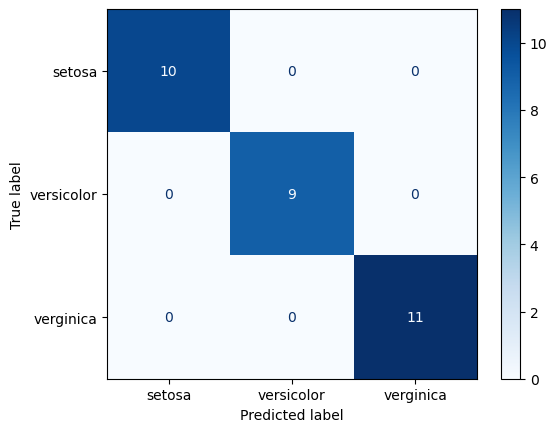

In [404]:
from sklearn.metrics import ConfusionMatrixDisplay
class_names = ['setosa','versicolor','verginica']
normalize= None
ConfusionMatrixDisplay.from_estimator(
    classifier,
    x_test,
    y_test,
    display_labels = class_names,
    cmap= plt.cm.Blues,
    normalize = normalize, #se utiliza en dado caso de que el set de prueba tuviera una mayor de datos que el set de entrenamiento que no sea 80 - 20 clasico,
)

#si se presenta otros numeros diferentes de 0 en los cuadrantes quiere decir que se confundio el modelo, en este caso hubiera aparecido falsos positivos
#La semilla nos permite ser repicable nuestros experimentos, no es un hiperparametro

In [405]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

#nos ayudar a ver si hay un balance entre recall y f1-score
#accuracy = exactitud 
#nos salio perfecto

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



**EXTRA: podemos ver con nuestro set de prueba el número de errores promedio que tendríamos con distintas K's

In [406]:
error = []

for i in range(1,100):
    knn = KNeighborsClassifier(n_neighbors= i)
    knn.fit(x_train,y_train) 
    pred_i= knn.predict(x_test)
    error.append(np.mean(pred_i !=y_test)) #Calcula el promedio de errores que obtuvimos para las pruebas con la k
    
error
#nuestra k es la 11, tanto arriba y abajo tuvimos 0

[np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.03333333333333333),
 np.float64(0.03333333333333333),
 np.float64(0.03333333333333333),
 np.float64(0.03333333333333333),
 np.float64(0.03333333333333333),
 np.float64(0.03333333333333333),
 np.float64(0.03333333333333333),
 np.float64(0.03333333333333333),
 np.float64(0.03333333333333333),
 np.float64(0.03333333333333333),
 np.float64(0.03333333333333333),
 np.float64(0.03333333333333333),
 np.float64(0.03333333333333333),
 np.float64(0.03333333333333333),
 np.float64(0.03333333333333333),
 np.

(0.0, 0.2)

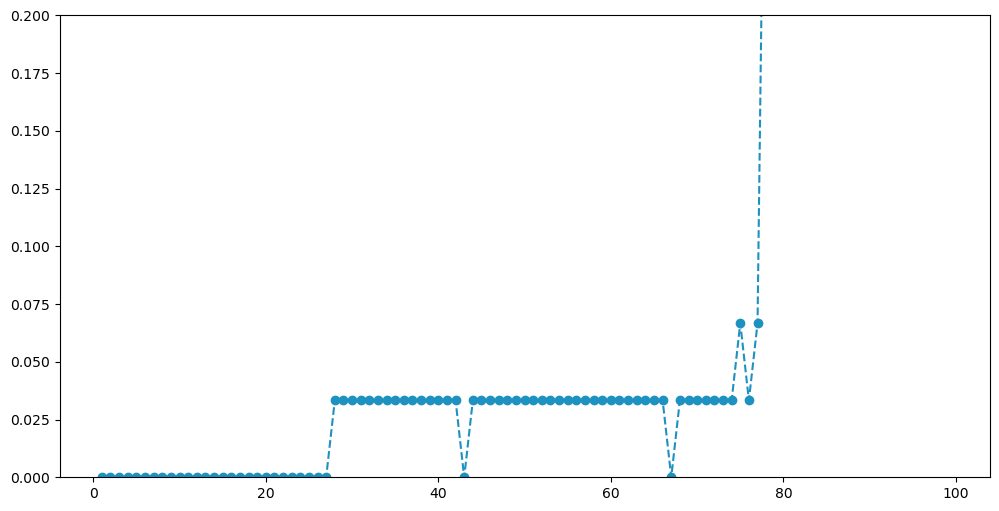

In [407]:
plt.figure(figsize=(12,6))
plt.plot(range(1,100), error, color = '#1d91c0', linestyle = 'dashed', marker= 'o')
plt.ylim(0,0.2)
#la K que nos de mejor rendimiento esa vamos a elegir

# Challenge: Cancer data

## Objetivo:
Detectar los tumores malignos y beningnos mediante el dataset que recaba múltiples características

1. Aplicar el algoritmo de KNN a ([data.csv](https://drive.google.com/file/d/18f1srPV-Bwp_JH_t4_eujW1MgY1H3rZv/view?usp=drive_link))
2. Evaluar el rendimiento del modelo

In [408]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

%matplotlib inline

In [409]:
df = pd.read_csv('C:/Users/space/Downloads/data.csv')
df.head()
#M= maligno
#B = Benigno
#El modelo debe identifica si es M y B , Hay que entrenarlo con este conjunto de datos

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [410]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


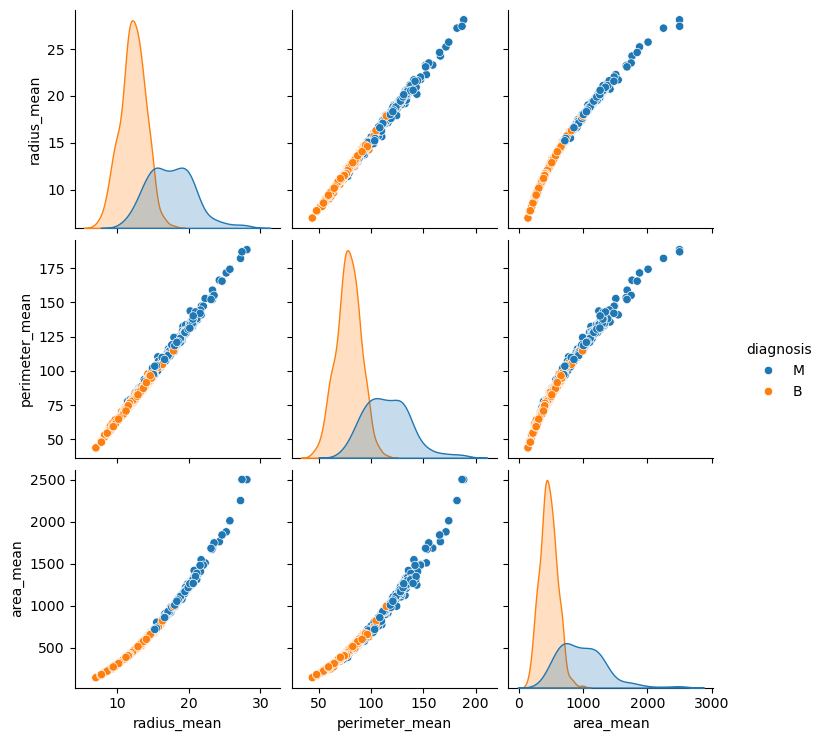

In [411]:
sns.pairplot(data=df, x_vars = ['radius_mean', 'perimeter_mean', 'area_mean'], y_vars = ['radius_mean', 'perimeter_mean', 'area_mean'], hue='diagnosis')

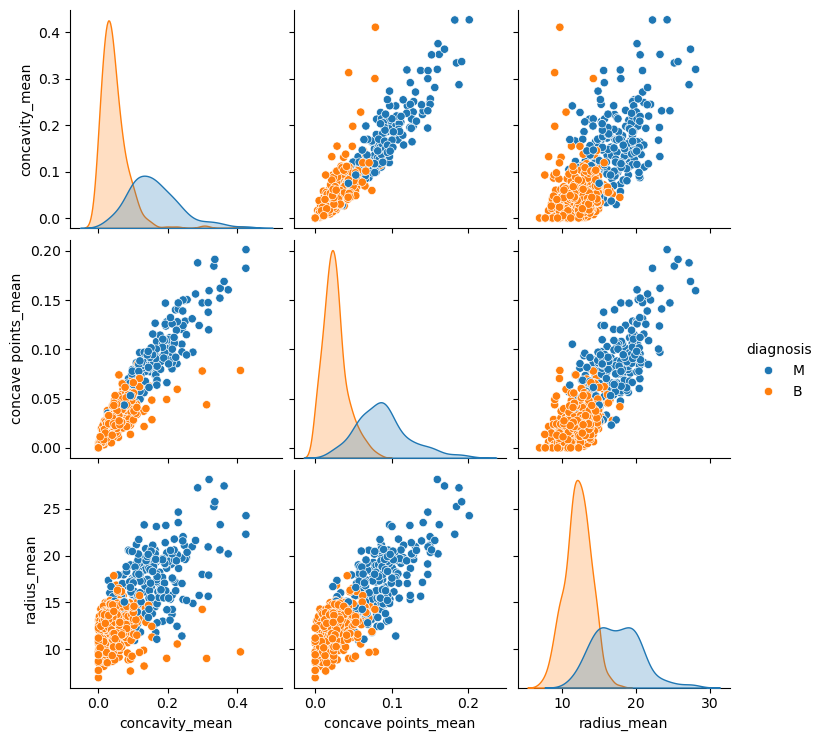

In [412]:
features = ['concavity_mean', 'concave points_mean', 'radius_mean']

sns.pairplot(df, vars=features, hue='diagnosis', diag_kind='kde')
plt.show()

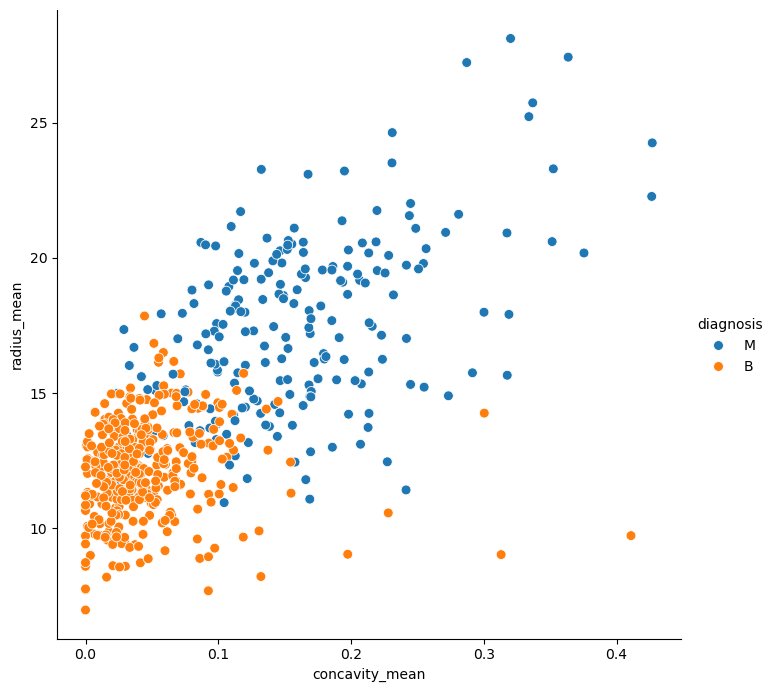

In [413]:
sns.pairplot(data=df, x_vars = 'concavity_mean', y_vars = 'radius_mean',plot_kws={'s':50}, height= 7  ,hue='diagnosis')

In [414]:
#Quiero obtener estos datos en formato de arreglo, lo hace numpy, no en un data frame
x = df.iloc[: , 2 : -1 ].values
x

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [415]:
#estamos asegurando que los datos tengan una correspondencia de 1 a 1
#Procurar no hacer reordenamiento para conservar los indices, para que los valores de predicción coincidan con los valores de entrenamiento
y = df.iloc[:, 1].values
y

array(['M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M',
       'M', 'M', 'M', 'M', 'M', 'M', 'B', 'B', 'B', 'M', 'M', 'M', 'M',
       'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'B', 'M',
       'M', 'M', 'M', 'M', 'M', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'B',
       'B', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'M',
       'M', 'B', 'B', 'B', 'B', 'M', 'B', 'M', 'M', 'B', 'M', 'B', 'M',
       'M', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'M', 'M', 'B', 'B', 'B',
       'M', 'B', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'B', 'B',
       'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'M', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'M',
       'B', 'M', 'M', 'B', 'M', 'M', 'B', 'B', 'M', 'B', 'B', 'M', 'B',
       'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B',
       'M', 'B', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'B', 'B', 'M', 'M',
       'B', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'M

In [416]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state= 42) #Aquí separa en set de entrenamiento y un set de prueba, se pasa aquí las puras features (solo caracteristicas , no respuestas), y el valor semilla nos permite hacer el muestreo aleotorio de los datos de la misma manera
#En test size los valores intermedio, es ilogico valores de 0 o 1 porque esos son los valores que va entrenar, en este caso el 0.2 representa el 20% de los datos
#estos son los valores de entrada: x_train = variable de entrenamiento, luego la de prueba, en otra variable vendrá las respuestas del entrenamiento y_train, y luego las respuestas de la prueba (80%)

In [417]:
#Conjunto de entrenamiento
print(x_train)
len(x_train)

[[9.029e+00 1.733e+01 5.879e+01 ... 1.750e-01 4.228e-01 1.175e-01]
 [2.109e+01 2.657e+01 1.427e+02 ... 2.903e-01 4.098e-01 1.284e-01]
 [9.173e+00 1.386e+01 5.920e+01 ... 5.087e-02 3.282e-01 8.490e-02]
 ...
 [1.429e+01 1.682e+01 9.030e+01 ... 3.333e-02 2.458e-01 6.120e-02]
 [1.398e+01 1.962e+01 9.112e+01 ... 1.827e-01 3.179e-01 1.055e-01]
 [1.218e+01 2.052e+01 7.722e+01 ... 7.431e-02 2.694e-01 6.878e-02]]


455

In [418]:
#Conjunto de prueba
print(x_test)
len(x_test)

[[1.247e+01 1.860e+01 8.109e+01 ... 1.015e-01 3.014e-01 8.750e-02]
 [1.894e+01 2.131e+01 1.236e+02 ... 1.789e-01 2.551e-01 6.589e-02]
 [1.546e+01 1.948e+01 1.017e+02 ... 1.514e-01 2.837e-01 8.019e-02]
 ...
 [1.152e+01 1.493e+01 7.387e+01 ... 9.608e-02 2.664e-01 7.809e-02]
 [1.422e+01 2.785e+01 9.255e+01 ... 8.219e-02 1.890e-01 7.796e-02]
 [2.073e+01 3.112e+01 1.357e+02 ... 1.659e-01 2.868e-01 8.218e-02]]


114

In [419]:
import math
math.sqrt(len(x_train))

21.330729007701542

In [420]:
from sklearn.preprocessing import  MinMaxScaler  #Een este caso es un escalador de minimos y máximos, nos sirve para resolver este problema de que los min y máximos no coinciden. Nos dimos cuenta en nuestro resumen estadístico.
scaler = MinMaxScaler(feature_range =(0,1)) #por defecto necesita un min y un max en este caso del 0 al 1, puedo poner del 0 - 50 , que te haga sentido que se te haga manejable e interpretable
scaler.fit(x_train) #porque son los datos que el modelo va a conocer, lo que entreneraron y ya estan normalizado, de lo contrario van a estar desacoplados, por lo tanto unicamente en el set de entrenamiento

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [421]:
# El scaler soalo se ajusta a los datos de entrenamiento.
# Una vez ajustado, podemos utilizarlo para los datos de entrenamiento y de prueba

x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)
x_test

array([[0.23404672, 0.30064254, 0.23595106, ..., 0.34879725, 0.2856298 ,
        0.27517803],
       [0.55090847, 0.39228948, 0.53834116, ..., 0.61477663, 0.19436231,
        0.09198033],
       [0.38047897, 0.33040243, 0.38255797, ..., 0.52027491, 0.25073921,
        0.21320787],
       ...,
       [0.18752143, 0.17653027, 0.1845924 , ..., 0.33017182, 0.2166371 ,
        0.19540522],
       [0.31975121, 0.61345959, 0.31747048, ..., 0.28243986, 0.06406466,
        0.19430315],
       [0.63857192, 0.72404464, 0.62441315, ..., 0.57010309, 0.25684999,
        0.23007799]], shape=(114, 30))

In [422]:
#hiperparametro: parámetro de un algoritmo de machine learning que adquiere un determinado valor para ajustarse correctamente a los datos  y=beta(x) + alpha , como L1 , L2 Regresión Lasso.
x_train.min(), x_train.max()

(np.float64(0.0), np.float64(1.0000000000000002))

In [423]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 21 ) #Ya la calculamos
classifier.fit(x_train, y_train)

,n_neighbors,21
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [424]:
#Aqui hacemos la matriz de confusión que contiene un las clasificaciones de las respuestas correctas y del otro eje las que obtuvo el modelo
y_pred = classifier.predict(x_test)
y_pred

array(['B', 'M', 'M', 'B', 'B', 'M', 'M', 'M', 'M', 'B', 'B', 'M', 'B',
       'M', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B',
       'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'M',
       'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'M',
       'M', 'B', 'B', 'B', 'B', 'M', 'M', 'B', 'B', 'M', 'M', 'B', 'B',
       'B', 'M', 'M', 'B', 'B', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'B',
       'B', 'B', 'M', 'B', 'B', 'M', 'M', 'M', 'M', 'M', 'B', 'B', 'B',
       'B', 'B', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'M', 'B', 'M', 'M',
       'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'M'], dtype=object)

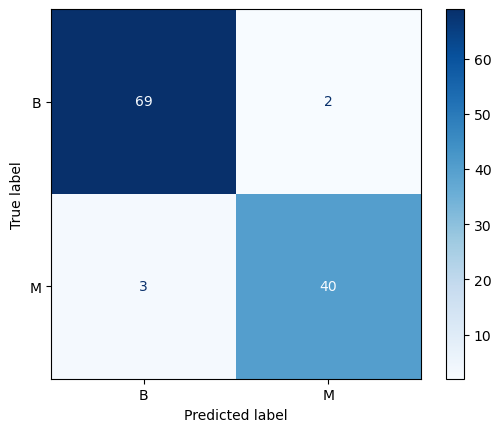

In [425]:
from sklearn.metrics import ConfusionMatrixDisplay
class_names = ['B','M']
ConfusionMatrixDisplay.from_estimator(
    classifier,
    x_test,
    y_test,
    display_labels = class_names,
    cmap= plt.cm.Blues,
  )

#si se presenta otros numeros diferentes de 0 en los cuadrantes quiere decir que se confundio el modelo, en este caso hubiera aparecido falsos positivos
#La semilla nos permite ser repicable nuestros experimentos, no es un hiperparametro

In [426]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

#nos ayudar a ver si hay un balance entre recall y f1-score
#accuracy = exactitud
#nos salio perfecto

              precision    recall  f1-score   support

           B       0.96      0.97      0.97        71
           M       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [427]:
error = []

for i in range(1,100):
    knn = KNeighborsClassifier(n_neighbors= i)
    knn.fit(x_train,y_train)
    pred_i= knn.predict(x_test)
    error.append(np.mean(pred_i !=y_test)) #Calcula el promedio de errores que obtuvimos para las pruebas con la k

error


[np.float64(0.043859649122807015),
 np.float64(0.02631578947368421),
 np.float64(0.03508771929824561),
 np.float64(0.02631578947368421),
 np.float64(0.03508771929824561),
 np.float64(0.02631578947368421),
 np.float64(0.03508771929824561),
 np.float64(0.03508771929824561),
 np.float64(0.03508771929824561),
 np.float64(0.05263157894736842),
 np.float64(0.043859649122807015),
 np.float64(0.043859649122807015),
 np.float64(0.043859649122807015),
 np.float64(0.03508771929824561),
 np.float64(0.03508771929824561),
 np.float64(0.043859649122807015),
 np.float64(0.03508771929824561),
 np.float64(0.03508771929824561),
 np.float64(0.043859649122807015),
 np.float64(0.043859649122807015),
 np.float64(0.043859649122807015),
 np.float64(0.043859649122807015),
 np.float64(0.043859649122807015),
 np.float64(0.05263157894736842),
 np.float64(0.05263157894736842),
 np.float64(0.05263157894736842),
 np.float64(0.05263157894736842),
 np.float64(0.05263157894736842),
 np.float64(0.05263157894736842),
 np.

(0.0, 0.2)

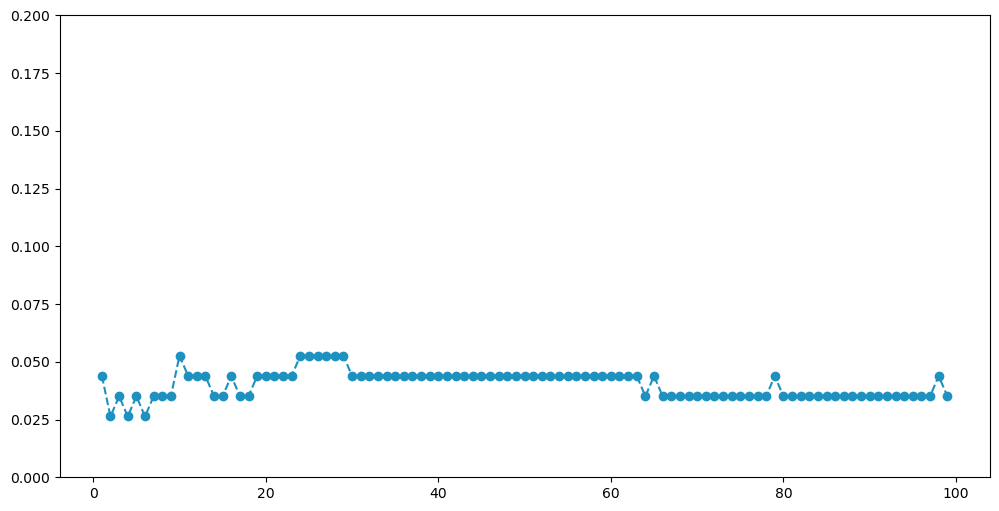

In [428]:
plt.figure(figsize=(12,6))
plt.plot(range(1,100), error, color = '#1d91c0', linestyle = 'dashed', marker= 'o')
plt.ylim(0,0.2)
#la K que nos de mejor rendimiento esa vamos a elegir

# Challenge: Wine Quality data

## Objetivo:
Determinar la calidad del vino con base en su características

1. Aplicar el algoritmo de KNN a Wine Quality Data que se encuentra dentro del siguiente link 👇🏼

> https://archive.ics.uci.edu/ml/datasets/Wine+Quality

2. Evaluar el rendimiento del modelo

In [445]:
# 1. URLs de los archivos
url_red = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
url_white = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

# 2. Leer los archivos (usando sep=';')
red_wine = pd.read_csv(url_red, sep=';')
white_wine = pd.read_csv(url_white, sep=';')

# 3. Añadir columna identificadora
red_wine['color'] = 'red'
white_wine['color'] = 'white'

# 4. Concatenar ambos DataFrames
# ignore_index=True ayuda a que el índice sea continuo en lugar de repetirse
wine_df = pd.concat([red_wine, white_wine], ignore_index=True)
wine_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white


In [446]:
wine_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


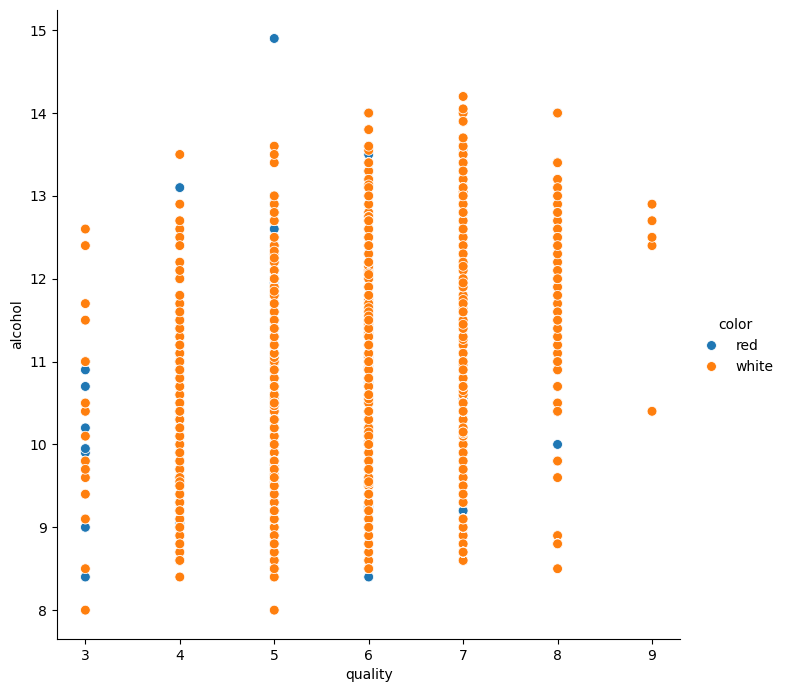

In [453]:
sns.pairplot(x_vars='quality', y_vars='alcohol', data= wine_df, plot_kws={'s':50}, height= 7  ,hue= 'color')

In [455]:
x = wine_df.iloc[: , 0:12].values
x

array([[ 7.4 ,  0.7 ,  0.  , ...,  0.56,  9.4 ,  5.  ],
       [ 7.8 ,  0.88,  0.  , ...,  0.68,  9.8 ,  5.  ],
       [ 7.8 ,  0.76,  0.04, ...,  0.65,  9.8 ,  5.  ],
       ...,
       [ 6.5 ,  0.24,  0.19, ...,  0.46,  9.4 ,  6.  ],
       [ 5.5 ,  0.29,  0.3 , ...,  0.38, 12.8 ,  7.  ],
       [ 6.  ,  0.21,  0.38, ...,  0.32, 11.8 ,  6.  ]], shape=(6497, 12))

In [457]:
y = wine_df.iloc[:, 12].values
y

array(['red', 'red', 'red', ..., 'white', 'white', 'white'],
      shape=(6497,), dtype=object)

In [458]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state= 42)

In [459]:
#Conjunto de entrenamiento
print(x_train)
len(x_train)

[[6.60e+00 2.40e-01 3.50e-01 ... 3.70e-01 1.05e+01 5.00e+00]
 [8.30e+00 2.80e-01 4.80e-01 ... 6.20e-01 1.24e+01 7.00e+00]
 [7.70e+00 7.15e-01 1.00e-02 ... 5.70e-01 1.18e+01 6.00e+00]
 ...
 [6.40e+00 3.70e-01 2.00e-01 ... 4.30e-01 9.50e+00 5.00e+00]
 [6.50e+00 2.60e-01 5.00e-01 ... 4.70e-01 9.50e+00 5.00e+00]
 [7.20e+00 6.20e-01 6.00e-02 ... 5.40e-01 9.50e+00 5.00e+00]]


5197

In [460]:
#Conjunto de prueba
print(x_test)
len(x_test)

[[ 7.    0.17  0.74 ...  0.38 12.2   8.  ]
 [ 7.7   0.64  0.21 ...  0.45  9.9   5.  ]
 [ 6.8   0.39  0.34 ...  0.44 12.    7.  ]
 ...
 [ 6.6   0.16  0.35 ...  0.75 12.4   7.  ]
 [ 6.6   0.39  0.38 ...  0.57  9.4   6.  ]
 [ 7.4   0.16  0.27 ...  0.43  8.7   7.  ]]


1300

In [461]:
import math
math.sqrt(len(x_train))

72.09022125087424

In [462]:
from sklearn.preprocessing import  MinMaxScaler  #Een este caso es un escalador de minimos y máximos, nos sirve para resolver este problema de que los min y máximos no coinciden. Nos dimos cuenta en nuestro resumen estadístico.
scaler = MinMaxScaler(feature_range =(0,1)) #por defecto necesita un min y un max en este caso del 0 al 1, puedo poner del 0 - 50 , que te haga sentido que se te haga manejable e interpretable
scaler.fit(x_train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [463]:
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)
x_test

array([[0.27118644, 0.06      , 0.60162602, ..., 0.08988764, 0.67741935,
        0.83333333],
       [0.33050847, 0.37333333, 0.17073171, ..., 0.12921348, 0.30645161,
        0.33333333],
       [0.25423729, 0.20666667, 0.27642276, ..., 0.12359551, 0.64516129,
        0.66666667],
       ...,
       [0.23728814, 0.05333333, 0.28455285, ..., 0.29775281, 0.70967742,
        0.66666667],
       [0.23728814, 0.20666667, 0.30894309, ..., 0.19662921, 0.22580645,
        0.5       ],
       [0.30508475, 0.05333333, 0.2195122 , ..., 0.11797753, 0.11290323,
        0.66666667]], shape=(1300, 12))

In [464]:
x_train.min(), x_train.max()

(np.float64(0.0), np.float64(1.0))

In [466]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 72) #Ya la calculamos, fue k que nos dió 10.99 aprox
classifier.fit(x_train, y_train)

,n_neighbors,72
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [467]:
y_pred = classifier.predict(x_test)
y_pred

array(['white', 'red', 'white', ..., 'white', 'white', 'white'],
      shape=(1300,), dtype=object)

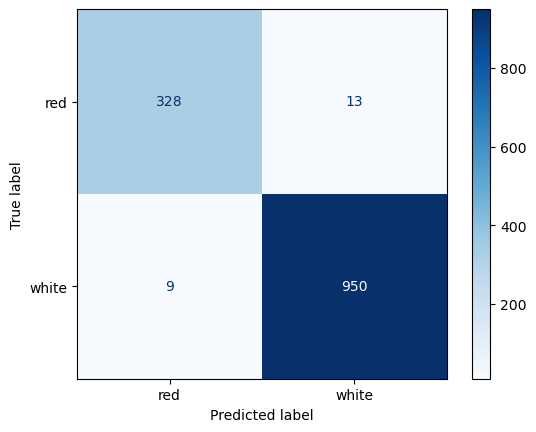

In [468]:
from sklearn.metrics import ConfusionMatrixDisplay
class_names = ['red','white']
normalize= None
ConfusionMatrixDisplay.from_estimator(
    classifier,
    x_test,
    y_test,
    display_labels = class_names,
    cmap= plt.cm.Blues,
    normalize = normalize, #se utiliza en dado caso de que el set de prueba tuviera una mayor de datos que el set de entrenamiento que no sea 80 - 20 clasico,
)

In [472]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         red       0.97      0.96      0.97       341
       white       0.99      0.99      0.99       959

    accuracy                           0.98      1300
   macro avg       0.98      0.98      0.98      1300
weighted avg       0.98      0.98      0.98      1300



In [470]:
error = []

for i in range(1,100):
    knn = KNeighborsClassifier(n_neighbors= i)
    knn.fit(x_train,y_train)
    pred_i= knn.predict(x_test)
    error.append(np.mean(pred_i !=y_test)) #Calcula el promedio de errores que obtuvimos para las pruebas con la k

error


[np.float64(0.011538461538461539),
 np.float64(0.016923076923076923),
 np.float64(0.013846153846153847),
 np.float64(0.013846153846153847),
 np.float64(0.013076923076923076),
 np.float64(0.011538461538461539),
 np.float64(0.013076923076923076),
 np.float64(0.013076923076923076),
 np.float64(0.012307692307692308),
 np.float64(0.011538461538461539),
 np.float64(0.013076923076923076),
 np.float64(0.012307692307692308),
 np.float64(0.013076923076923076),
 np.float64(0.013076923076923076),
 np.float64(0.013076923076923076),
 np.float64(0.012307692307692308),
 np.float64(0.012307692307692308),
 np.float64(0.013076923076923076),
 np.float64(0.012307692307692308),
 np.float64(0.011538461538461539),
 np.float64(0.013076923076923076),
 np.float64(0.012307692307692308),
 np.float64(0.011538461538461539),
 np.float64(0.012307692307692308),
 np.float64(0.012307692307692308),
 np.float64(0.011538461538461539),
 np.float64(0.013076923076923076),
 np.float64(0.013076923076923076),
 np.float64(0.013846

(0.0, 0.2)

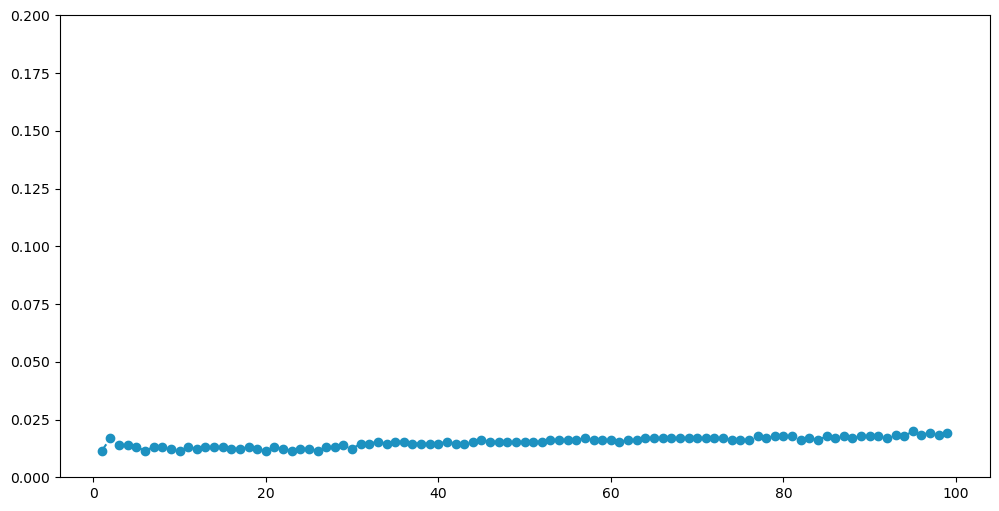

In [471]:
plt.figure(figsize=(12,6))
plt.plot(range(1,100), error, color = '#1d91c0', linestyle = 'dashed', marker= 'o')
plt.ylim(0,0.2)